비지도학습 3

In [16]:
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 데이터 로드 및 특성 선택
df = pd.read_csv('ai_data/winequality-red.csv')

X_wine = df.drop('quality', axis = 1)
y = df['quality']

In [5]:
# 데이터 표준화
scaler = StandardScaler()

x_wine_scaled = scaler.fit_transform(X_wine)

In [ ]:
# KMeans 모델 생성 및 예측
kmeans = KMeans(
    n_clusters=3,
    n_init='auto',
    random_state=42
)

wine_labels = kmeans.fit_predict(x_wine_scaled)

# 결과용 데이터 프레임 생성 후 클러스터 레이블 추가
df_result = df.copy()
df_result['Cluster'] = wine_labels
print('군집화 완료')

군집화 완료


In [ ]:
# 실루엣 계수 계산
wine_sil_score = silhouette_score(x_wine_scaled, wine_labels)
print(f'실루엣 계수 : {wine_sil_score}')

실루엣 계수 : 0.1892040681108649


In [13]:
# 각 클러스터별 특성의 평균값 비교
print('='*30)
print('클러스터별 특성 평균 비교')
print('='*30)
print(df_result.groupby('Cluster').mean())

# 각 클러스터가 와인 품질 점수와 관련이 있는지 확인
print('='*30)
print('클러스터와 와인 품질의 관련성')
print('='*30)
print(df_result.groupby('Cluster')['quality'].mean())

클러스터별 특성 평균 비교
         fixed acidity  volatile acidity  citric acid  residual sugar  \
Cluster                                                                 
0             7.189889          0.609342     0.123047        2.214058   
1            10.067131          0.405080     0.469761        2.582570   
2             8.155467          0.535173     0.289680        3.105467   

         chlorides  free sulfur dioxide  total sulfur dioxide   density  \
Cluster                                                                   
0         0.078553            13.507618             34.894737  0.995896   
1         0.100460            10.888446             30.627490  0.997574   
2         0.087235            27.108000             89.954667  0.997276   

               pH  sulphates    alcohol   quality  
Cluster                                            
0        3.405762   0.609224  10.494044  5.552632  
1        3.195040   0.752131  10.724037  5.960159  
2        3.284267   0.626533   9.88

In [ ]:
# PCA를 통해 데이터를 2차원으로 축소
pca = PCA(n_components=2)
X_wine_pca = pca.fit_transform(x_wine_scaled)

print(pca.explained_variance_ratio_)

# 군집의 중간점 역시 PCA를 통해 2차원으로 차원 축소
center_pca = pca.transform(kmeans.cluster_centers_)

[0.28173931 0.1750827 ]


C:\Users\EZ\AppData\Local\Temp\ipykernel_10596\3995900562.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Text(0, 0.5, 'PCA 2')

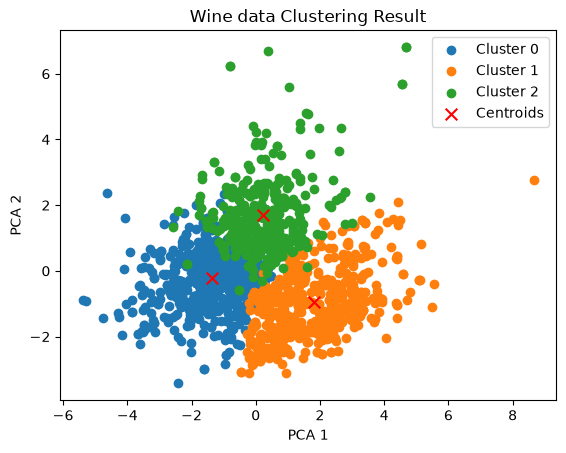

In [20]:
# 군집 산점도 그리기
for cluster in range(3):
    plt.scatter(
        X_wine_pca[wine_labels==cluster, 0],
        X_wine_pca[wine_labels==cluster, 1],
        cmap='viridis',
        label = f'Cluster {cluster}'
    )

# 군집 중간점 그리기
plt.scatter(
    center_pca[:,0],
    center_pca[:,1],
    c='red',
    marker='x',
    s=70,
    label='Centroids'
)
plt.legend()
plt.title('Wine data Clustering Result')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

실루엣 점수에서도 알 수 있었듯 군집 간의 경계가 명확하다고 보기는 어렵다.